# NLP Project 5: Social Media Comment Analysis



## 0. Imports & Setup

In [1]:
import re
import random
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)
SEED = 21
random.seed(SEED)
np.random.seed(SEED)

In [2]:
PLATFORMS = ["Twitter", "Instagram", "Facebook", "YouTube", "Reddit"]

PRODUCTS = ["NovaBuds Pro", "NovaBook Air", "NovaWatch Fit"]

POSITIVE_TEMPLATES = [
    "Just got my {p} and I'm blown away, the {feat} is fantastic! {tag}",
    "Honestly the {p} exceeded expectations, {feat} works flawlessly. {tag}",
    "Been using the {p} for a week, {feat} is a total game changer. {tag}",
    "{p} is worth every penny, love the {feat}. {tag}",
    "Huge fan of the new {p}, especially the {feat}. Highly recommend! {tag}",
]

NEGATIVE_TEMPLATES = [
    "Really disappointed with my {p}, the {feat} keeps failing. {tag}",
    "Not happy with the {p} at all, {feat} is buggy and slow. {tag}",
    "Regret buying the {p}, {feat} stopped working after two days. {tag}",
    "{p} customer support was unhelpful about my {feat} issue. {tag}",
    "Would not recommend the {p}, {feat} is a letdown. {tag}",
]

NEUTRAL_TEMPLATES = [
    "Anyone know if the {p} supports the {feat} update yet? {tag}",
    "Comparing the {p} against last year's model before I decide. {tag}",
    "Saw the {p} ad during the game, curious about the {feat}. {tag}",
    "Picking up the {p} tomorrow, will report back on the {feat}. {tag}",
    "Is the {p} {feat} available in every region? {tag}",
]

FEATURES = ["battery life", "build quality", "noise cancellation", "screen",
            "camera", "app integration", "delivery speed", "price", "design"]

HASHTAGS = ["#NovaLaunch", "#TechReview", "#NovaTech", "#GadgetLife",
            "#NewDrop", "#UnboxNova", "#WorthIt"]

def generate_dataset(n=260):
    rows = []
    start = pd.Timestamp("2026-06-01")
    for i in range(1, n + 1):
        label = random.choices(
            ["pos", "neg", "neu"], weights=[0.42, 0.33, 0.25], k=1
        )[0]
        template = random.choice(
            POSITIVE_TEMPLATES if label == "pos"
            else NEGATIVE_TEMPLATES if label == "neg"
            else NEUTRAL_TEMPLATES
        )
        text = template.format(
            p=random.choice(PRODUCTS),
            feat=random.choice(FEATURES),
            tag=random.choice(HASHTAGS),
        )
        if random.random() < 0.3:
            text += " " + random.choice(HASHTAGS)
        if random.random() < 0.4:
            text += " @NovaTechCare"
        if random.random() < 0.3:
            text += " https://t.co/nova" + str(random.randint(100, 999))

        rows.append({
            "comment_id": i,
            "platform": random.choice(PLATFORMS),
            "timestamp": start + pd.Timedelta(hours=random.randint(0, 24 * 30)),
            "likes": max(0, int(np.random.exponential(12))),
            "replies": max(0, int(np.random.exponential(3))),
            "raw_comment": text,
        })
    return pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)

df = generate_dataset()
print(f"Collected {len(df)} comments across platforms: {df['platform'].unique().tolist()}")
df.head()

Collected 260 comments across platforms: ['Twitter', 'Facebook', 'Reddit', 'YouTube', 'Instagram']


,comment_id,platform,timestamp,likes,replies,raw_comment
0,205,Twitter,2026-06-01 07:00:00,9,6,Anyone know if the NovaBook Air supports the s...
1,44,Facebook,2026-06-01 11:00:00,9,2,"Would not recommend the NovaWatch Fit, build q..."
2,259,Reddit,2026-06-01 12:00:00,10,2,"Huge fan of the new NovaWatch Fit, especially ..."
3,70,Facebook,2026-06-01 13:00:00,1,2,"Really disappointed with my NovaBook Air, the ..."
4,256,YouTube,2026-06-01 19:00:00,51,0,"Would not recommend the NovaWatch Fit, battery..."


In [3]:
STOPWORDS = set('''a an and are as at be by for from has have i if in is it its
of on or that the this to was were will with you your my me we our they them he she
his her just really not no so very much been being do does did can could would should
about get got novabuds novabook novawatch pro air fit'''.split())

def extract_hashtags(text):
    return re.findall(r"#(\w+)", text)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(text):
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]

df["hashtags"] = df["raw_comment"].apply(extract_hashtags)
df["clean_comment"] = df["raw_comment"].apply(clean_text)
df["tokens"] = df["clean_comment"].apply(tokenize)
df["token_count"] = df["tokens"].apply(len)

df[["raw_comment", "clean_comment", "hashtags", "token_count"]].head()

,raw_comment,clean_comment,hashtags,token_count
0,Anyone know if the NovaBook Air supports the s...,anyone know if the novabook air supports the s...,[WorthIt],6
1,"Would not recommend the NovaWatch Fit, build q...",would not recommend the novawatch fit build qu...,[NovaTech],4
2,"Huge fan of the new NovaWatch Fit, especially ...",huge fan of the new novawatch fit especially t...,[UnboxNova],7
3,"Really disappointed with my NovaBook Air, the ...",really disappointed with my novabook air the d...,"[TechReview, TechReview]",4
4,"Would not recommend the NovaWatch Fit, battery...",would not recommend the novawatch fit battery ...,"[UnboxNova, NovaLaunch]",4


In [4]:
POSITIVE_WORDS = {
    "love": 3, "amazing": 3, "fantastic": 3, "flawlessly": 2, "great": 2,
    "recommend": 2, "worth": 2, "exceeded": 2, "gamechanger": 3, "changer": 2,
    "fan": 2, "blown": 2, "away": 1, "expectations": 1, "highly": 1, "best": 3,
    "excellent": 3, "happy": 2, "good": 1, "quality": 1, "fast": 1,
}

NEGATIVE_WORDS = {
    "disappointed": -3, "regret": -3, "buggy": -2, "slow": -2, "unhelpful": -2,
    "letdown": -3, "stopped": -2, "failing": -2, "worst": -3, "bad": -2,
    "issue": -1, "problem": -1, "broken": -2, "poor": -2, "waste": -2,
}

INTENSIFIERS = {"really", "very", "extremely", "totally", "highly", "absolutely"}
NEGATIONS = {"not", "no", "never", "cant", "cannot", "wont", "didnt"}

def score_sentiment(tokens):
    score, i, intensity = 0.0, 0, 1.0
    negate = False
    for tok in tokens:
        if tok in INTENSIFIERS:
            intensity = 1.6
            continue
        if tok in NEGATIONS:
            negate = True
            continue
        weight = POSITIVE_WORDS.get(tok, 0) + NEGATIVE_WORDS.get(tok, 0)
        if weight != 0:
            adj = weight * intensity
            score += -adj if negate else adj
        intensity = 1.0
        negate = False
    return score / max(len(tokens), 1)

def label_sentiment(score):
    if score > 0.15:
        return "Positive"
    if score < -0.15:
        return "Negative"
    return "Neutral"

df["sentiment_score"] = df["tokens"].apply(score_sentiment)
df["sentiment"] = df["sentiment_score"].apply(label_sentiment)

df["sentiment"].value_counts()

sentiment
Positive    108
Negative     79
Neutral      73
Name: count, dtype: int64

In [5]:
all_hashtags = [h for tags in df["hashtags"] for h in tags]
trending_tags = Counter(all_hashtags).most_common(10)

all_words = [w for tokens in df["tokens"] for w in tokens]
trending_words = Counter(all_words).most_common(15)

print("Top hashtags:", trending_tags[:5])
print("Top words   :", trending_words[:5])

Top hashtags: [('UnboxNova', 56), ('TechReview', 52), ('NovaTech', 50), ('NewDrop', 45), ('NovaLaunch', 44)]
Top words   : [('every', 42), ('build', 40), ('quality', 40), ('recommend', 37), ('noise', 33)]


In [6]:
corpus = df["clean_comment"].tolist()
tfidf = TfidfVectorizer(max_features=300, min_df=2, stop_words="english")
X_tfidf = tfidf.fit_transform(corpus)

N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
df["cluster"] = kmeans.fit_predict(X_tfidf)

terms = np.array(tfidf.get_feature_names_out())
order = kmeans.cluster_centers_.argsort()[:, ::-1]

print("Top terms per KMeans cluster:")
for c in range(N_CLUSTERS):
    top_terms = terms[order[c, :6]]
    print(f"  Cluster {c} ({(df['cluster'] == c).sum()} comments): {', '.join(top_terms)}")

Top terms per KMeans cluster:
  Cluster 0 (67 comments): slow, happy, buggy, report, tomorrow, picking
  Cluster 1 (92 comments): region, available, love, penny, worth, pro
  Cluster 2 (37 comments): recommend, new, highly, huge, especially, fan
  Cluster 3 (64 comments): update, supports, know, just, im, got


In [7]:
count_X = tfidf.transform(corpus)
lda = LatentDirichletAllocation(n_components=4, random_state=SEED, max_iter=15)
lda.fit(X_tfidf)

print("Top terms per LDA topic:")
for idx, comp in enumerate(lda.components_):
    top_terms = terms[comp.argsort()[::-1][:6]]
    print(f"  Topic {idx}: {', '.join(top_terms)}")

Top terms per LDA topic:
  Topic 0: worth, love, penny, supports, update, know
  Topic 1: region, available, life, battery, fantastic, im
  Topic 2: recommend, new, highly, huge, especially, fan
  Topic 3: slow, happy, buggy, report, tomorrow, picking


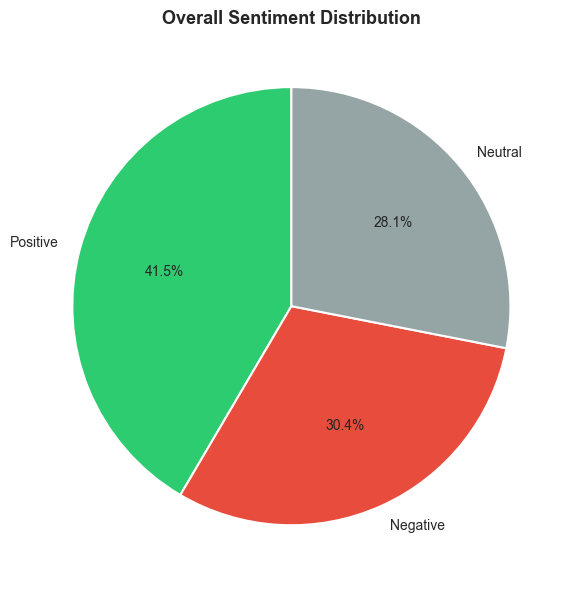

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df["sentiment"].value_counts()
colors = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}
ax.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
       colors=[colors[l] for l in counts.index],
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Overall Sentiment Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

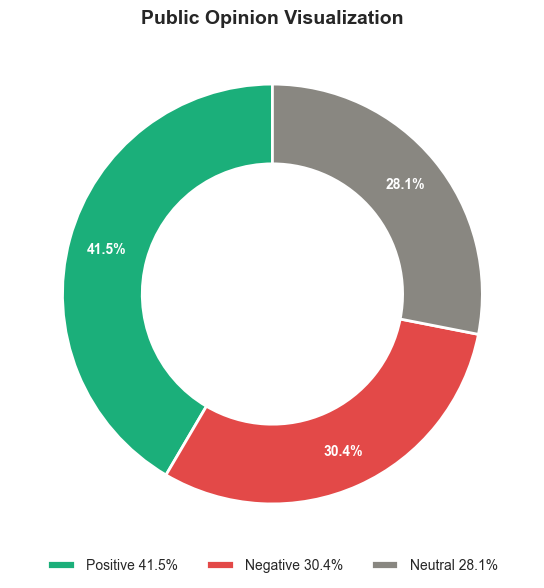

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
donut_colors = {"Positive": "#1baf7a", "Neutral": "#898781", "Negative": "#e34948"}
wedges, _, autotexts = ax.pie(
    counts, labels=None, autopct="%1.1f%%", startangle=90, pctdistance=0.82,
    colors=[donut_colors[l] for l in counts.index],
    wedgeprops={"edgecolor": "white", "linewidth": 2, "width": 0.38},
)
for t in autotexts:
    t.set_color("white")
    t.set_fontweight("bold")
ax.legend(wedges, [f"{l} {v/counts.sum()*100:.1f}%" for l, v in counts.items()],
          loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
ax.set_title("Public Opinion Visualization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

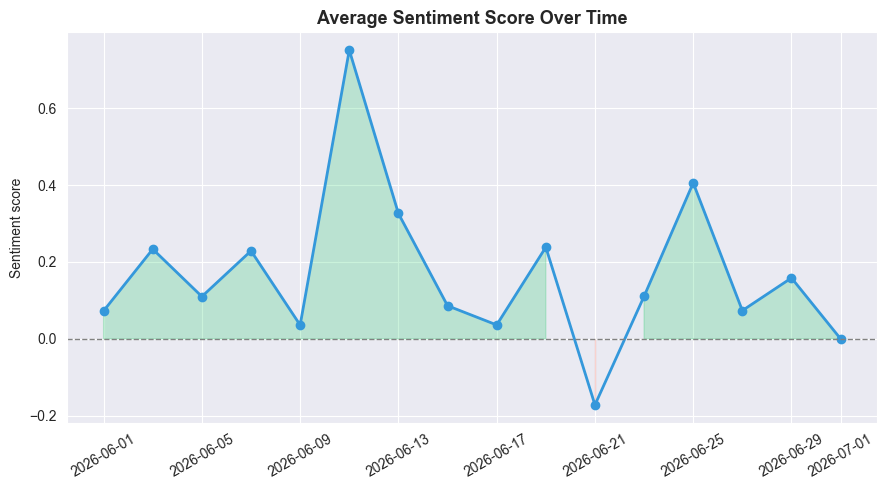

In [10]:
daily = df.set_index("timestamp").resample("2D")["sentiment_score"].mean()

fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, marker="o", color="#3498db", linewidth=2)
ax.axhline(0, color="grey", linestyle="--", linewidth=1)
ax.fill_between(daily.index, daily.values, 0,
                 where=(daily.values >= 0), color="#2ecc71", alpha=0.25)
ax.fill_between(daily.index, daily.values, 0,
                 where=(daily.values < 0), color="#e74c3c", alpha=0.25)
ax.set_title("Average Sentiment Score Over Time", fontsize=13, fontweight="bold")
ax.set_ylabel("Sentiment score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

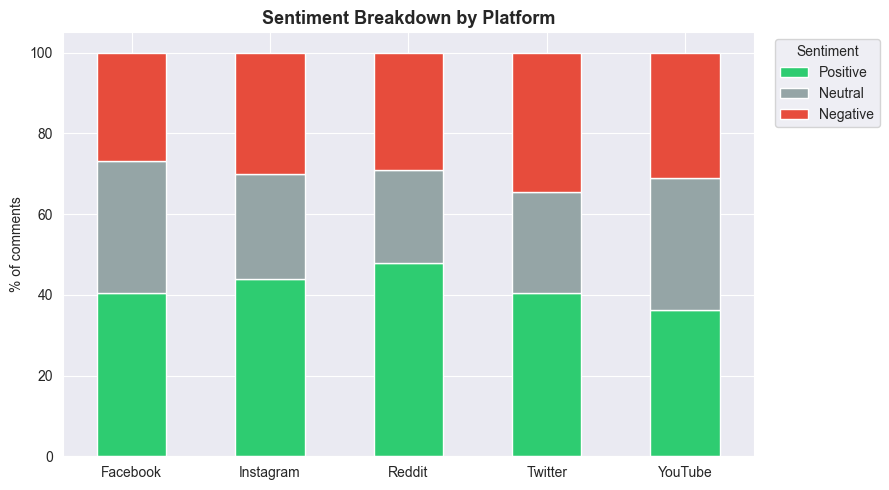

In [11]:
plat_sent = pd.crosstab(df["platform"], df["sentiment"], normalize="index") * 100
plat_sent = plat_sent[["Positive", "Neutral", "Negative"]]

ax = plat_sent.plot(kind="bar", stacked=True,
                     color=[colors["Positive"], colors["Neutral"], colors["Negative"]],
                     figsize=(9, 5))
ax.set_title("Sentiment Breakdown by Platform", fontsize=13, fontweight="bold")
ax.set_ylabel("% of comments")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

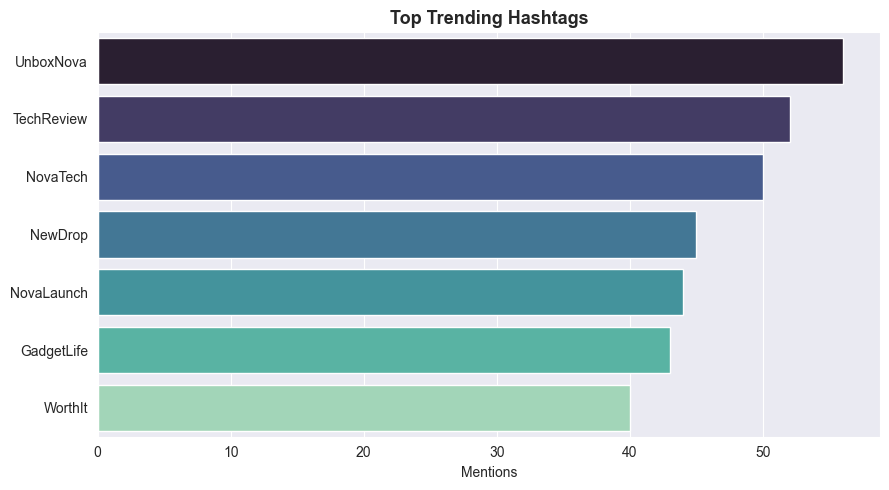

In [12]:
tags, tag_counts = zip(*trending_tags[:8])
fig, ax = plt.subplots()
sns.barplot(x=list(tag_counts), y=list(tags), hue=list(tags), palette="mako", legend=False, ax=ax)
ax.set_title("Top Trending Hashtags", fontsize=13, fontweight="bold")
ax.set_xlabel("Mentions")
plt.tight_layout()
plt.show()

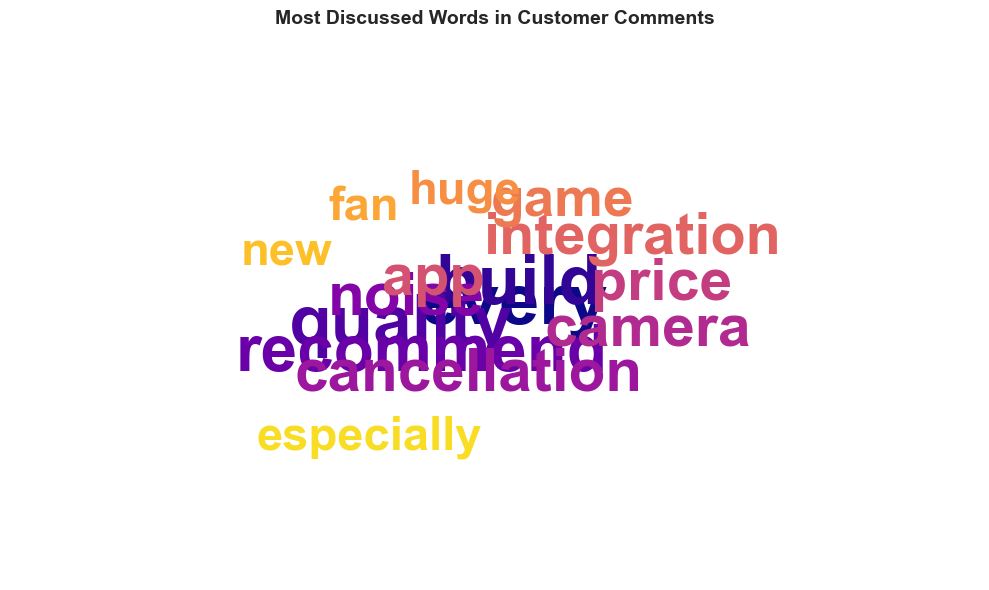

In [13]:
def plot_word_sizes(word_counts, title):
    """Simple frequency-sized word layout on a spiral, avoiding overlap."""
    fig, ax = plt.subplots(figsize=(10, 6))
    max_count = max(c for _, c in word_counts)
    cmap = plt.get_cmap("plasma")
    placed_boxes = []

    def overlaps(x, y, w, h):
        for (px, py, pw, ph) in placed_boxes:
            if abs(x - px) < (w + pw) / 2 and abs(y - py) < (h + ph) / 2:
                return True
        return False

    rng = random.Random(11)
    for i, (word, count) in enumerate(word_counts):
        size = 12 + (count / max_count) * 40
        angle, radius = 0.0, 0.02
        placed = False
        for _ in range(200):
            x = 0.5 + radius * np.cos(angle)
            y = 0.5 + radius * np.sin(angle)
            w, h = 0.02 * len(word), 0.03
            if 0.03 < x < 0.97 and 0.03 < y < 0.97 and not overlaps(x, y, w, h):
                placed_boxes.append((x, y, w, h))
                placed = True
                break
            angle += 0.5
            radius += 0.012
        if not placed:
            x, y = rng.uniform(0.1, 0.9), rng.uniform(0.1, 0.9)
        ax.text(x, y, word, fontsize=size, color=cmap(i / len(word_counts)),
                ha="center", va="center", fontweight="bold")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_word_sizes(trending_words, "Most Discussed Words in Customer Comments")

In [14]:
total = len(df)
pos_pct = (df["sentiment"] == "Positive").mean() * 100
neu_pct = (df["sentiment"] == "Neutral").mean() * 100
neg_pct = (df["sentiment"] == "Negative").mean() * 100

print("SOCIAL MEDIA COMMENT ANALYSIS - SUMMARY REPORT")
print("=" * 52)
print(f"Total comments analyzed : {total}")
print(f"Positive sentiment       : {pos_pct:.1f}%")
print(f"Neutral sentiment        : {neu_pct:.1f}%")
print(f"Negative sentiment       : {neg_pct:.1f}%")
print()
print("Top trending hashtags    :", [t for t, _ in trending_tags[:5]])
print("Top discussed words      :", [w for w, _ in trending_words[:5]])
print()
verdict = "largely positive" if pos_pct > neg_pct else "mixed to negative"
print(f"Overall public perception is {verdict}, with strongest attention around:")
print(", ".join(w for w, _ in trending_words[:3]))

SOCIAL MEDIA COMMENT ANALYSIS - SUMMARY REPORT
Total comments analyzed : 260
Positive sentiment       : 41.5%
Neutral sentiment        : 28.1%
Negative sentiment       : 30.4%

Top trending hashtags    : ['UnboxNova', 'TechReview', 'NovaTech', 'NewDrop', 'NovaLaunch']
Top discussed words      : ['every', 'build', 'quality', 'recommend', 'noise']

Overall public perception is largely positive, with strongest attention around:
every, build, quality


## Conclusion

This notebook walks through a full NLP pipeline for social media comment analysis:
simulated collection, cleaning/tokenization, a custom lexicon-based sentiment scorer,
topic discovery via TF-IDF/KMeans and LDA, and a set of visualizations (sentiment split,
sentiment trend over time, platform breakdown, hashtag ranking, and a frequency-sized
word layout). To run it on real data, replace `generate_dataset()` with
`pd.read_csv('your_export.csv')` — every step downstream works unchanged as long as the
dataframe has a text column to feed into `clean_text`.